### ============================================================
### HOUSE PRICE PREDICTION - MACHINE LEARNING REGRESSION
### ==========================================================


── TASK 1: Import Required Libraries ─────────────────────

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


── TASK 2: Load the Dataset ──────────────────────────────


In [3]:
df = pd.read_csv('house_price_regression_dataset.csv')
print(f"✅ Dataset loaded — {df.shape[0]} rows × {df.shape[1]} columns")


✅ Dataset loaded — 1000 rows × 8 columns


── TASK 3: Check Dataset ─────────────────────────────────

In [4]:
print("\n── Shape ─────────────────────────────────────────────")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n── First 5 rows ──────────────────────────────────────")
print(df.head())

print("\n── Data Types & Non-Null Counts ──────────────────────")
print(df.info())

print("\n── Statistical Summary ───────────────────────────────")
print(df.describe())


── Shape ─────────────────────────────────────────────
Rows: 1000, Columns: 8

── First 5 rows ──────────────────────────────────────
   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  

── Data Types & Non-Null Counts ──────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 ent

── TASK 4: Handle Missing Values ────────────────────────

In [5]:
print("\n── Missing Values ────────────────────────────────────")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


── Missing Values ────────────────────────────────────
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Total missing values: 0


── TASK 5: Remove Duplicate Records ─────────────────────

In [6]:
print("\n── Duplicate Records ─────────────────────────────────")
print(f"Duplicates before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after : {df.duplicated().sum()}")
print(f"Dataset shape    : {df.shape}")


── Duplicate Records ─────────────────────────────────
Duplicates before: 0
Duplicates after : 0
Dataset shape    : (1000, 8)


── TASK 6: Univariate Analysis ───────────────────────────


── Univariate Analysis ───────────────────────────────


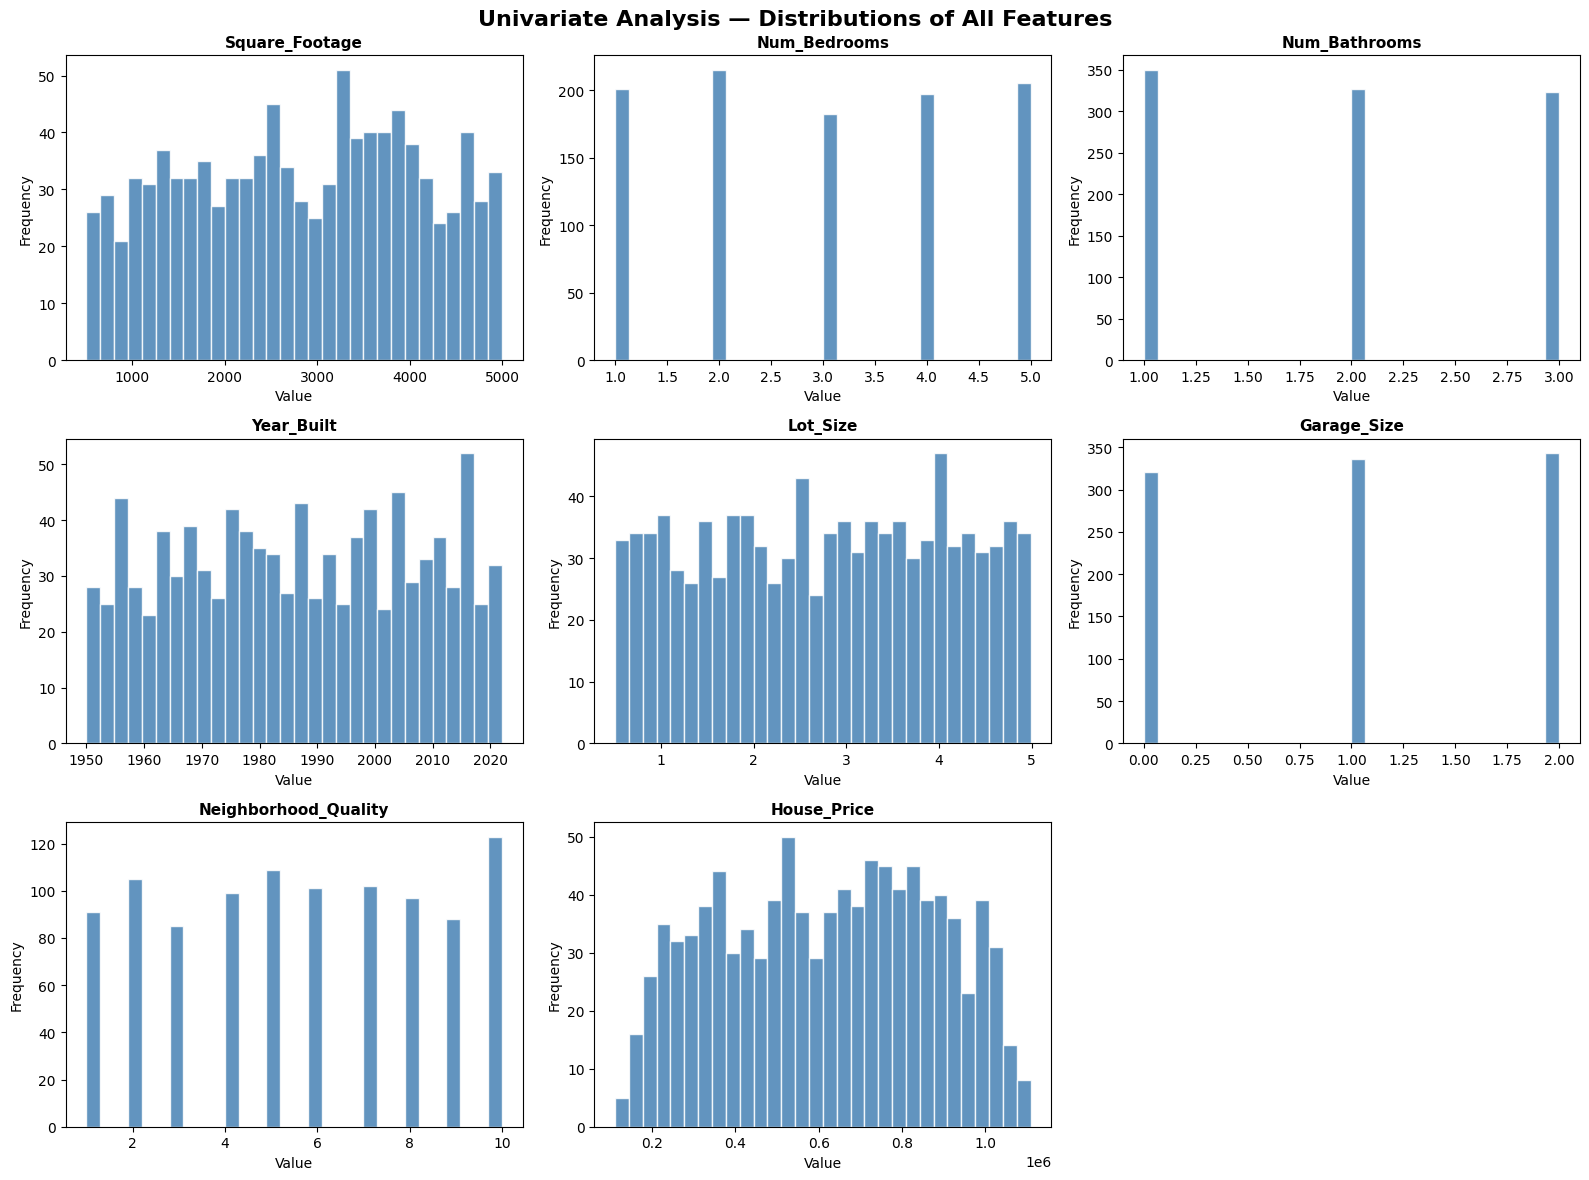

✅ Univariate plots saved


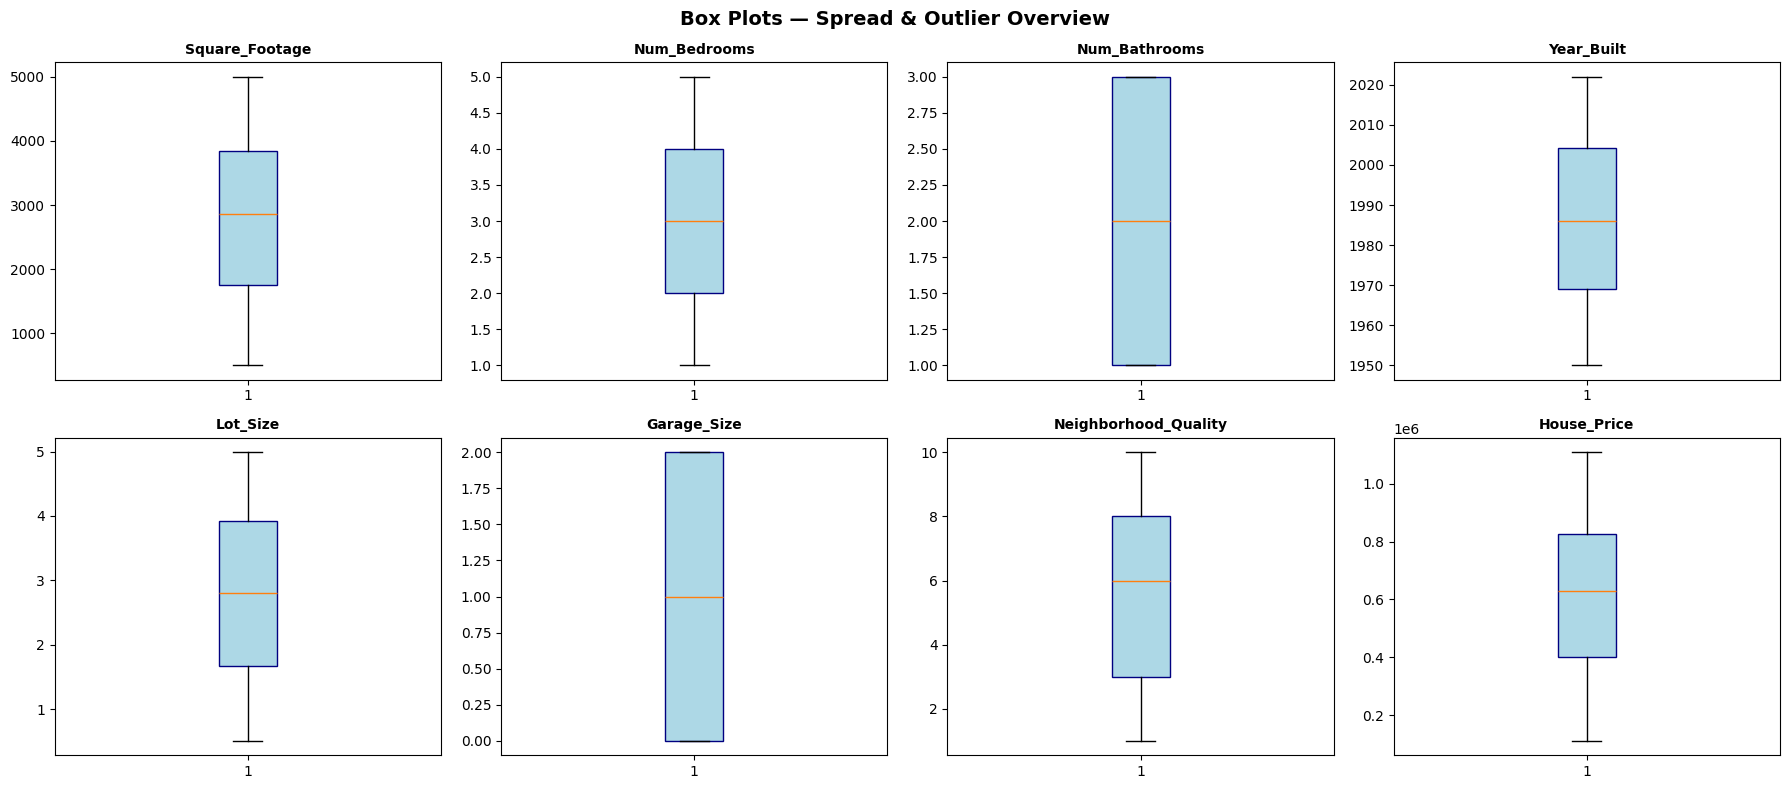

In [7]:
print("\n── Univariate Analysis ───────────────────────────────")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Univariate Analysis — Distributions of All Features',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide the 9th subplot if we have 8 columns
if len(df.columns) < 9:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Univariate plots saved")

# Box plots for spread + outlier detection at a glance
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Box Plots — Spread & Outlier Overview', fontsize=14, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_univariate.png', dpi=150, bbox_inches='tight')
plt.show()


── TASK 7: Bivariate Analysis ───────────────────────────


── Bivariate Analysis ───────────────────────────────


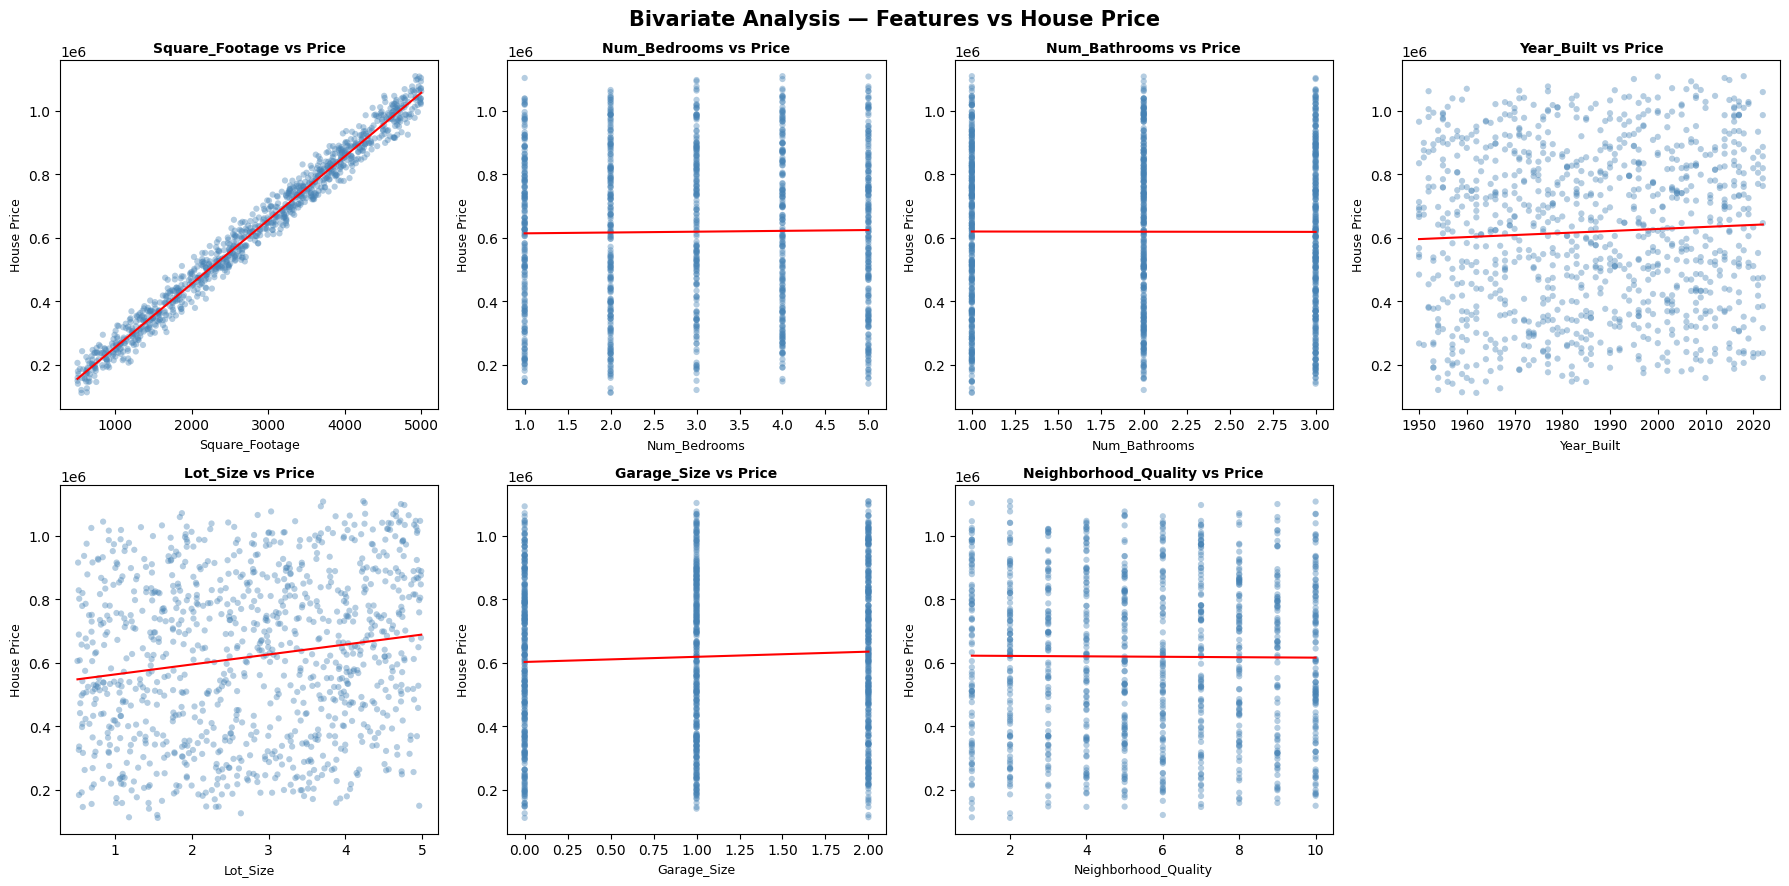

✅ Bivariate scatter plots saved


In [8]:
print("\n── Bivariate Analysis ───────────────────────────────")

features = [c for c in df.columns if c != 'House_Price']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Bivariate Analysis — Features vs House Price',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['House_Price'],
                    alpha=0.4, color='steelblue', edgecolors='none', s=20)
    # Regression trend line
    m, b = np.polyfit(df[col], df['House_Price'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('House Price', fontsize=9)
    axes[i].set_title(f'{col} vs Price', fontsize=10, fontweight='bold')

if len(features) < 8:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bivariate scatter plots saved")

── TASK 8: Correlation Heatmap ──────────────────────────


── Correlation Heatmap ──────────────────────────────


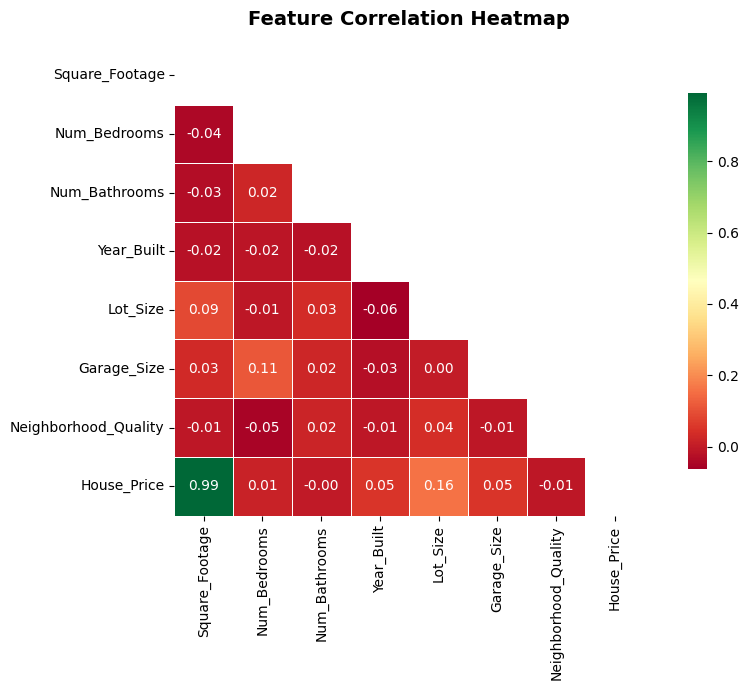


Top correlations with House_Price:
House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


In [9]:
print("\n── Correlation Heatmap ──────────────────────────────")

plt.figure(figsize=(10, 7))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 10}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with House_Price:")
print(corr_matrix['House_Price'].sort_values(ascending=False))

── TASK 9: Detect and Handle Outliers ───────────────────

In [10]:
print("\n── Outlier Detection & Removal (IQR Method) ─────────")

df_clean = df.copy()
outlier_report = {}

for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report[col] = n_out

print(pd.Series(outlier_report, name='Outlier Count'))

# Cap outliers using IQR (Winsorization) instead of removing rows
for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f"\nShape before outlier handling: {df.shape}")
print(f"Shape after  outlier handling: {df_clean.shape}")
print("✅ Outliers capped using IQR Winsorization")



── Outlier Detection & Removal (IQR Method) ─────────
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
Name: Outlier Count, dtype: int64

Shape before outlier handling: (1000, 8)
Shape after  outlier handling: (1000, 8)
✅ Outliers capped using IQR Winsorization


── TASK 10: Encoding ─────────────────────────────────────

In [11]:
print("\n── Encoding ─────────────────────────────────────────")
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    print(f"Categorical columns found: {categorical_cols}")
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
    print("✅ One-Hot Encoding applied")
else:
    print("No categorical columns found — encoding step skipped.")


── Encoding ─────────────────────────────────────────
No categorical columns found — encoding step skipped.


── TASK 11: Log Transformation ──────────────────────────


── Log Transformation on House_Price ────────────────


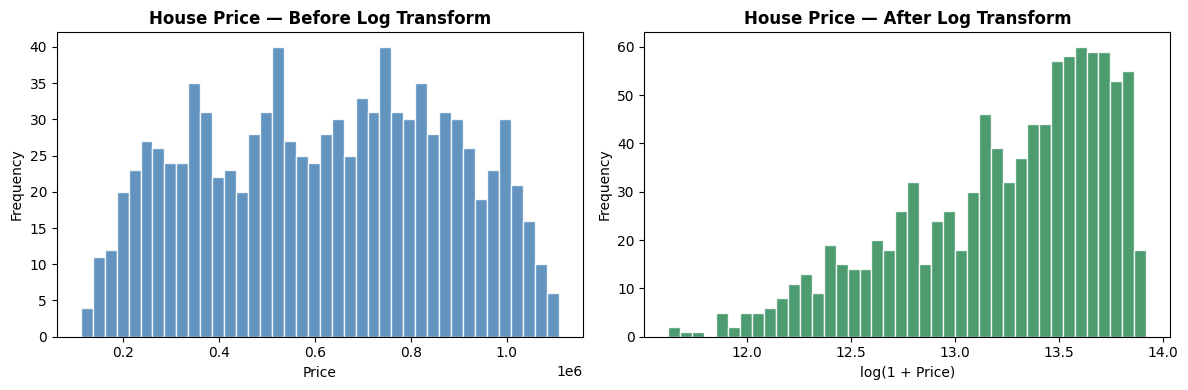

✅ Log transformation applied — new column: House_Price_Log
Skewness before: -0.0640
Skewness after : -0.8015


In [15]:
print("\n── Log Transformation on House_Price ────────────────")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['House_Price'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('House Price — Before Log Transform', fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency'
)

# Apply log transform
df_clean['House_Price_Log'] = np.log1p(df_clean['House_Price'])

axes[1].hist(df_clean['House_Price_Log'], bins=40, color='seagreen',
             edgecolor='white', alpha=0.85)
axes[1].set_title('House Price — After Log Transform', fontweight='bold')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('log_transform.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Log transformation applied — new column: House_Price_Log")

# Skewness comparison
print(f"Skewness before: {df_clean['House_Price'].skew():.4f}")
print(f"Skewness after : {df_clean['House_Price_Log'].skew():.4f}")

── TASK 12: Separate Features & Target ──────────────────

In [16]:
print("\n── Separate Features & Target ───────────────────────")

X = df_clean.drop(columns=['House_Price', 'House_Price_Log'])
y = df_clean['House_Price_Log']   # Using log-transformed target

print(f"Features shape : {X.shape}")
print(f"Target  shape  : {y.shape}")
print(f"Features used  : {list(X.columns)}")


── Separate Features & Target ───────────────────────
Features shape : (1000, 7)
Target  shape  : (1000,)
Features used  : ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']


── TASK 13: Train-Test Split ─────────────────────────────

In [17]:
print("\n── Train-Test Split (80 / 20) ────────────────────────")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")


── Train-Test Split (80 / 20) ────────────────────────
Training set  : (800, 7)
Test set      : (200, 7)


── TASK 14: Feature Scaling ──────────────────────────────

In [18]:
print("\n── Feature Scaling (StandardScaler) ─────────────────")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling complete — mean ≈ 0, std ≈ 1 for all features")


── Feature Scaling (StandardScaler) ─────────────────
✅ Scaling complete — mean ≈ 0, std ≈ 1 for all features


── TASK 15: Train Regression Models ─────────────────────


── Linear Regression ────────────────────────────────
Model       Linear Regression
MAE                  51521.69
MSE             4485156348.87
RMSE                 66971.31
MAPE (%)               9.3322
R²                     0.9304
Adj. R²                0.9279
dtype: object

── KNN Regression ───────────────────────────────────
Best K = 7 (CV R² = 0.8532)


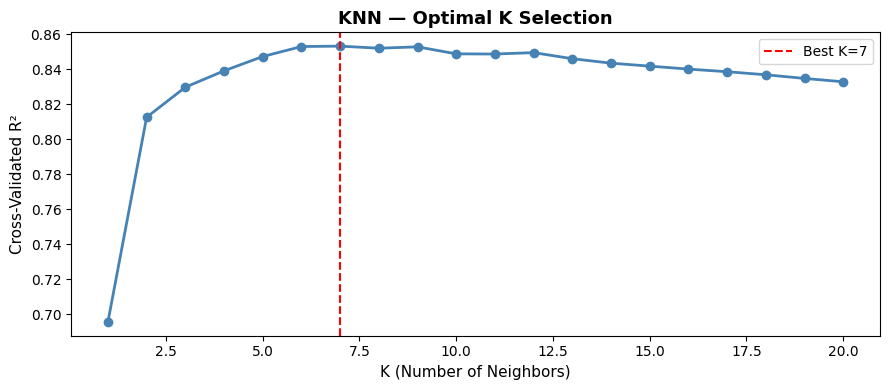

Model          KNN (k=7)
MAE             66519.04
MSE         6594884873.7
RMSE             81208.9
MAPE (%)         14.2473
R²                0.8977
Adj. R²            0.894
dtype: object


In [19]:
# Helper: compute all metrics
def evaluate_model(name, y_true, y_pred_log):
    # Inverse transform predictions from log space → original scale
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    mse  = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100
    r2   = r2_score(y_true_orig, y_pred_orig)

    n = len(y_true_orig)
    p = X_test_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    return {
        'Model'    : name,
        'MAE'      : round(mae, 2),
        'MSE'      : round(mse, 2),
        'RMSE'     : round(rmse, 2),
        'MAPE (%)'  : round(mape, 4),
        'R²'       : round(r2, 4),
        'Adj. R²'  : round(adj_r2, 4)
    }

results = []

# ── 15a: Linear Regression ────────────────────────────────
print("\n── Linear Regression ────────────────────────────────")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_metrics = evaluate_model('Linear Regression', y_test, lr_pred)
results.append(lr_metrics)
print(pd.Series(lr_metrics))

# ── 15b: KNN Regression ───────────────────────────────────
print("\n── KNN Regression ───────────────────────────────────")

# Find the best K using cross-validation on train set
from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train,
                             cv=5, scoring='r2')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f"Best K = {best_k} (CV R² = {max(k_scores):.4f})")

# K selection plot
plt.figure(figsize=(9, 4))
plt.plot(list(k_range), k_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)', fontsize=11)
plt.ylabel('Cross-Validated R²', fontsize=11)
plt.title('KNN — Optimal K Selection', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_metrics = evaluate_model(f'KNN (k={best_k})', y_test, knn_pred)
results.append(knn_metrics)
print(pd.Series(knn_metrics))

─ TASK 16: Evaluation Summary ──────────────────────────


══════════════════════════════════════════════════════
           MODEL PERFORMANCE COMPARISON               
══════════════════════════════════════════════════════
                        MAE           MSE      RMSE  MAPE (%)      R²  Adj. R²
Model                                                                         
Linear Regression  51521.69  4.485156e+09  66971.31    9.3322  0.9304   0.9279
KNN (k=7)          66519.04  6.594885e+09  81208.90   14.2473  0.8977   0.8940

🏆 Best Model by R² Score: Linear Regression


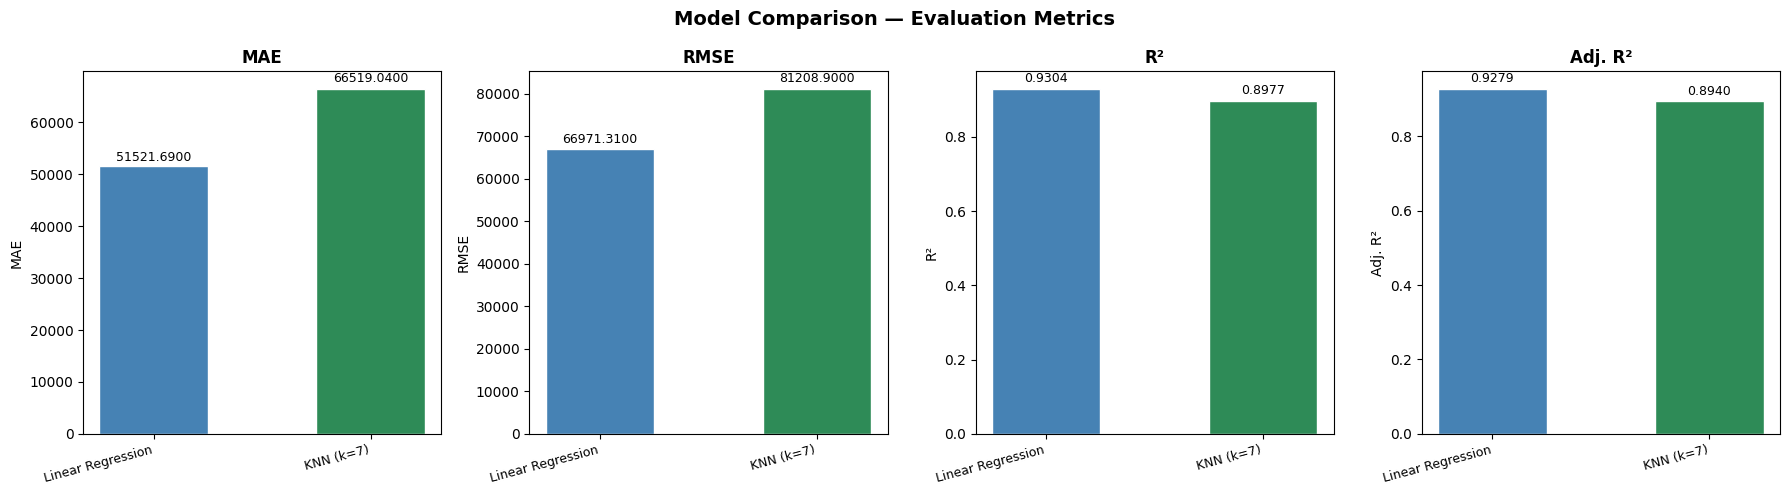

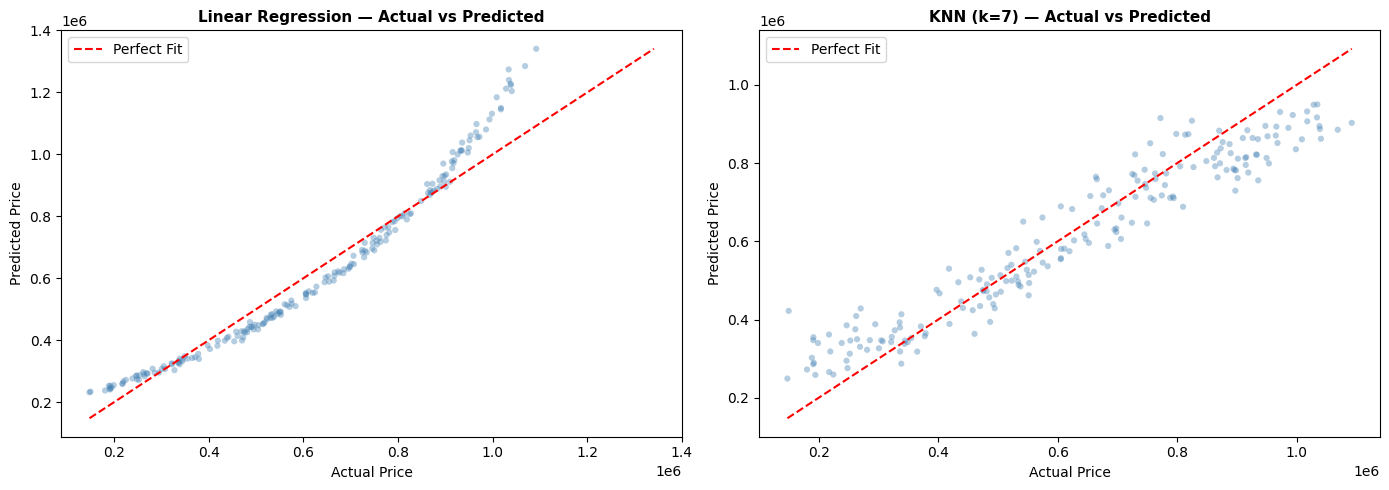

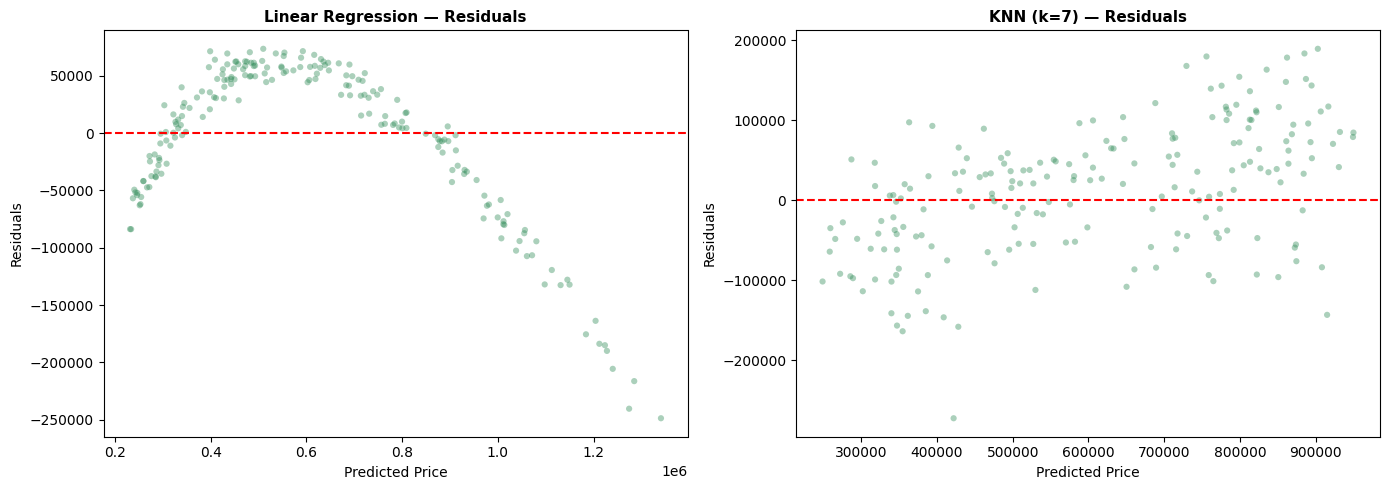


✅ All tasks completed. Figures saved to current directory.
════════════════════════════════════════════════════════
FINAL RESULTS SUMMARY
════════════════════════════════════════════════════════
                        MAE           MSE      RMSE  MAPE (%)      R²  Adj. R²
Model                                                                         
Linear Regression  51521.69  4.485156e+09  66971.31    9.3322  0.9304   0.9279
KNN (k=7)          66519.04  6.594885e+09  81208.90   14.2473  0.8977   0.8940

🏆 Best Model: Linear Regression


In [20]:
print("\n══════════════════════════════════════════════════════")
print("           MODEL PERFORMANCE COMPARISON               ")
print("══════════════════════════════════════════════════════")
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

best_model = results_df['R²'].idxmax()
print(f"\n🏆 Best Model by R² Score: {best_model}")

# ── Comparison Bar Chart ──────────────────────────────────
metrics_to_plot = ['MAE', 'RMSE', 'R²', 'Adj. R²']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Model Comparison — Evaluation Metrics',
             fontsize=14, fontweight='bold')

colors = ['steelblue', 'seagreen']
for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric].values
    bars = axes[i].bar(results_df.index, vals, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() * 1.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Actual vs Predicted Plot ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
preds   = [lr_pred, knn_pred]
names   = ['Linear Regression', f'KNN (k={best_k})']

for ax, pred, name in zip(axes, preds, names):
    y_true_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(pred)
    ax.scatter(y_true_orig, y_pred_orig,
               alpha=0.4, color='steelblue', s=20, edgecolors='none')
    mn = min(y_true_orig.min(), y_pred_orig.min())
    mx = max(y_true_orig.max(), y_pred_orig.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual Price', fontsize=10)
    ax.set_ylabel('Predicted Price', fontsize=10)
    ax.set_title(f'{name} — Actual vs Predicted', fontsize=11, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Residuals Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, name in zip(axes, preds, names):
    residuals = np.expm1(y_test) - np.expm1(pred)
    ax.scatter(np.expm1(pred), residuals,
               alpha=0.4, color='seagreen', s=20, edgecolors='none')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Price', fontsize=10)
    ax.set_ylabel('Residuals', fontsize=10)
    ax.set_title(f'{name} — Residuals', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All tasks completed. Figures saved to current directory.")
print("════════════════════════════════════════════════════════")
print("FINAL RESULTS SUMMARY")
print("════════════════════════════════════════════════════════")
print(results_df)
print(f"\n🏆 Best Model: {best_model}")